In [1]:
from utlis import *
from config import *
from data import *
from model import *
from trainer import *
#from sae import *
from transformers import BertTokenizer
from torch.utils.data import DataLoader
from torch.optim import AdamW


/Users/jesanahammed/Math498-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
from analysis import *

In [6]:
device = get_device()
datacon = DatasetConfig("/Users/jesanahammed/Desktop/IMDB/IMDB Dataset.csv", "csv", "review", "sentiment", 128)
modelcon = ModelConfig("bert-base-uncased", None)
tokenizer = BertTokenizer.from_pretrained(modelcon.model_name)

loader = DatasetLoader(datacon, tokenizer)
dataset, num_labels, label_map = loader.load()
print(num_labels)

modelcon.num_labels = num_labels

Map: 100%|██████████| 10000/10000 [00:01<00:00, 8021.22 examples/s]

2


In [7]:
trainingcon = TrainingConfig(32, 2, 2e-5, tokenizer)

In [8]:
train_loader = DataLoader(dataset["train"], batch_size=trainingcon.batch_size)
test_loader = DataLoader(dataset["test"], batch_size=trainingcon.batch_size)

In [9]:
model = BERTClassifier(modelcon, device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7818.01it/s]


In [10]:
optimizer = AdamW(model.model.parameters(), lr=trainingcon.lr)

In [11]:
trainer = Trainer(model.model, optimizer, device, datacon, trainingcon)

In [9]:
trainer.train(train_loader, trainingcon.epochs)

Epoch 0: Loss 0.3133
Epoch 1: Loss 0.1870


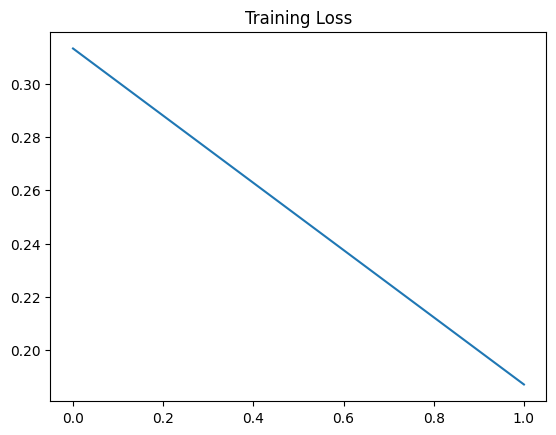

In [10]:
trainer.plot_loss()

In [11]:
trainer.evaluate(test_loader)

Confusion Matrix:
 [[4223  794]
 [ 344 4639]]


In [12]:
model.save("outputs/models/bert")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


In [12]:
model.load("outputs/models/bert")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7158.91it/s]


In [13]:
dataset.set_format(type=None)  # IMPORTANT

N = 200

texts = dataset["test"]["review"][:N]
true_labels = torch.tensor(dataset["test"]["label"][:N])

print(texts)
print(true_labels)

Y = trainer.get_bert_predictions(texts)
print(Y)

['Pathetic... worse than a bad made-for-TV movie. I can\'t believe that Spacey and Freeman were in this flick. For some reason Morgan Freeman\'s character is constantly talking about and saying "pussy" when referring to NSync boy\'s girlfriend. Morgan Freeman calling women "pussy" is just awkward... What the hell were the people behind this film thinking? Too many plot holes to imagine combined with the horrid acting, confusing camera angles, a lame script and cheap background music made this movie absolutely unbearable.<br /><br />I rented this flop with low expectations.... but... well... it really sucked.', "I found this film to be an utter dissapointment. The talent available to the director- notably Stanley Tucci, Chris Walken, Hank Azaria and Alan Arkin (without even mentioning the four main leads)- have been completely wasted on an unfunny, mediocre story, whose conclusion one couldn't really care about once introduced to the dire, stereo-typed characters. Julia Roberts is feebl

In [15]:
# saeconfig = gemmaConfig("google/gemma-2b", "gemma-scope-2b-pt-res-canonical", "layer_20/width_16k/canonical",
#                      2, texts, device
#                      )


In [12]:
# saeobj = GemmaScope(saeconfig)

In [3]:
# Z = saeobj.compute_sae_activation()

In [14]:
saeconfig = SAEConfig(
    model_name="gpt2",
    sae_release="gpt2-small-res-jb",
    sae_id="blocks.8.hook_resid_pre",
    layer=8,
    batch_size=4,
    texts=texts,
    device=device  # or "mps"
)

saeobj = ModelWithSAE(saeconfig)
Z = saeobj.compute_sae()
print(Z.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 264.29it/s]
/Users/jesanahammed/Math498-Project/.venv/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


torch.Size([200, 24576])


In [18]:
# import sae_lens

# print(dir(sae_lens))

['ActivationsStore', 'BatchTopKTrainingSAE', 'BatchTopKTrainingSAEConfig', 'CacheActivationsRunner', 'CacheActivationsRunnerConfig', 'GatedSAE', 'GatedSAEConfig', 'GatedTrainingSAE', 'GatedTrainingSAEConfig', 'HookedSAETransformer', 'JumpReLUSAE', 'JumpReLUSAEConfig', 'JumpReLUSkipTranscoder', 'JumpReLUSkipTranscoderConfig', 'JumpReLUTrainingSAE', 'JumpReLUTrainingSAEConfig', 'JumpReLUTranscoder', 'JumpReLUTranscoderConfig', 'LanguageModelSAERunnerConfig', 'LanguageModelSAETrainingRunner', 'LoggingConfig', 'MatchingPursuitSAE', 'MatchingPursuitSAEConfig', 'MatchingPursuitTrainingSAE', 'MatchingPursuitTrainingSAEConfig', 'MatryoshkaBatchTopKTrainingSAE', 'MatryoshkaBatchTopKTrainingSAEConfig', 'PretokenizeRunner', 'PretokenizeRunnerConfig', 'PretrainedSaeDiskLoader', 'PretrainedSaeHuggingfaceLoader', 'SAE', 'SAEConfig', 'SAETrainer', 'SAETrainingRunner', 'SAETransformerBridge', 'SkipTranscoder', 'SkipTranscoderConfig', 'StandardSAE', 'StandardSAEConfig', 'StandardTrainingSAE', 'Standard

In [28]:
# saeconfig = SAEConfig(
#     768, 5000, 1e-3, 32, 10, model, train_loader, 5000, device
# )

In [14]:
# import sys
# print(sys.executable)

/Users/jesanahammed/Math498-Project/.venv/bin/python


In [20]:
# from huggingface_hub import get_token

# token = get_token()
# print(token[:10] if token else None)

hf_OnNMfWc


In [9]:
# ts = trainsae(saeconfig)

In [24]:
# sae, H_norm, Y = ts.train_sae()

In [12]:
# Z = get_feature_activations(sae, H_norm, device)

In [17]:
def plot(Z):
    

    vals = Z.detach().cpu().numpy().flatten()

    plt.figure(figsize=(6,4))
    plt.hist(vals, bins=100)
    plt.title("Activation Distribution")
    plt.xlabel("Activation value")
    plt.ylabel("Frequency")
    plt.show()

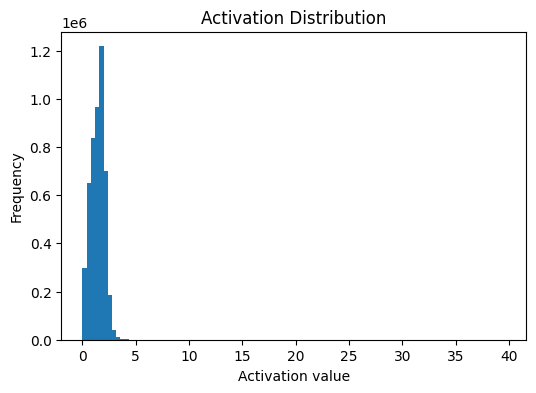

In [18]:
plot(Z)

In [15]:
importance = compute_feature_importance(Z, Y)
print(importance)
# top_features = get_top_features(importance, k=10)

# print("Top features:", top_features)

tensor([3.7131e-05, 1.9021e-04, 5.6366e-05,  ..., 4.1439e-04, 9.0687e-05,
        3.7105e-04])


In [16]:
p_values = compute_ttest(Z, Y)
reg_weights = compute_logistic_importance(Z, Y)

In [17]:
score = combine_scores(importance, p_values, reg_weights)

In [22]:
top_features = get_top_features(score, k=10)

print("Top features:", top_features)

Top features: tensor([18435, 20528, 18337,  6267, 18777, 15158, 19829, 13934,  8631,  3071])


In [23]:
dataset.set_format(type=None) 
for f in top_features:
    #print(dataset["train"].column_names)
    show_top_texts(f, Z, dataset, text_col=datacon.text_column)


===== Feature 18435 =====

I'm not usually into dark/psychological thriller type things. However, SEIZING ME is really an amazing piece of work. The story, acting, filming, psychological themes, erotic quality and spiritual understanding are all really quite complex and compelling. Rose plays the complexities and shifts of a psychologically disturbed woman really quite accurately. My partner was particularly impressed with the sophisticated way the power exchange issues were handled. It was so intense for us to watch that we found ourselves leaving it three quarters through to "get tea" and I felt compelled to have a shower. The story was gripping but we were clearly unable to handle all the energy in one straight shot. (It delves into the gritty and grimy side of people, but doesn't leave you there). I thought about the characters and deeper meanings for a long time. I would highly recommend this one. Still be prepared for an experience you might not be expecting.
---
As kids movie i

In [22]:

# def get_bottom_features(importance, k):
#     bottomk = torch.argsort(importance)[:k]
#     return bottomk
weak_features = get_bottom_features(importance, 10)
print(weak_features)

tensor([17730,  6787, 12205, 23053, 13390,  6983, 10112, 23975, 14634, 18649])


In [23]:
dataset.set_format(type=None) 
for f in weak_features:
    #print(dataset["train"].column_names)
    show_top_texts(f, Z, dataset, text_col=datacon.text_column)


===== Feature 17730 =====

First off I'd like to say that if I had to honestly rate this movie from a 1 to a 10, then I'd give it a -4. It's not that I'm a tough critic, it's just that this movie is THAT bad. Everything from the story, to the directing, to the editing is awful. The story is not even halfway decent to begin with (you can't expect much since it is based on a video game, something I was not aware of going into the movie) but the directing and editing made it even worse. The movie cuts at awkward points and goes to scenes that are completely unrelated to the previous ones; some, like a quick sex scene in the middle, don't even make sense being put into the story seeing as how the characters don't show any feelings toward each other. You could go into this movie expecting to see a pile of crap on the screen for an hour and a half and you'd still be disappointed. Honestly, if you pay to watch this movie then you are wasting your money, and if you don't pay anything then you